# Modeling

This notebook uses the features data from the folder data/processed and creates additional features.  

In [104]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from c08_farming_exit import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import shap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from econml.dml import CausalForestDML
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from econml.validate import DRTester


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
# #In case you want to run Stata in a cell using the magic command %%stata, initialize it first!
# from c08_farming_exit.stata_utils import init_stata
# init_stata()

## 1. Import features data

In [77]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

## 2. Preparation and inputs

In [78]:
geo_cols = ['district', 'enumeration_area', 'region'] #these columns are missing for Botwana and Namibia
identification_cols = ['personal_id',  'interview_key', 'members_id']
df = df.drop(columns = geo_cols + identification_cols)

Y = 'off_farm_hours_annual_share'
df = df.dropna(subset=Y) # can't train on unlabeled rows

T_input = [ 'land_size_cropland_acres',
            'land_size_fallow_acres',
            'land_size_agroforestry_forestry_acres',
            'land_size_pasture_acres']

T = 'agriculture_land_acres'

T_2 =   'land_number_of_plots'

X = [   'female',
        #'relation_to_head',
        'age',
        #'years_of_schooling',
        ]

W = [
        #geographics
        'country', 

        #socio-demographics
        'ethnic_group',
        'religion',
        'answered_for_self', 
    
        #land ownership
        'land_size_residential_acres',
        'land_size_lodge_camp_acres',
        'land_cropland_ownership_status',
        'land_residential_ownership_status',
        'grazing_land_ownership_status',
        'grazing_land_number_hh_sharing',
        'grazing_land_permit',
        'grazing_land_permit_price',
        'grazing_land_use_duration_in_years',

        #contracts/membership
        'livestock_contract',
        'crop_contract',
        'crop_contract_crop_type',
        'membership_farmers_group',
        'membership_agricultural_cooperative',

        #market distance and road quality
        'livestock_market_distance_in_km',
        'road_type',
        'road_condition',
        'road_distance_in_minutes',
        'market_output_distance_in_km',
        'market_input_distance_in_km',
        'market_type',

        #subsidies
        'subsidy',
        'subsidy_type_seeds',
        'subsidy_type_fertilizer',
        'subsidy_type_agro_chemicals',
        'subsidy_type_interest_free_loan',
        'subsidy_supplier_government',
        'subsidy_supplier_ngos',
        'subsidy_supplier_company',

        #assets
        'asset_value',
        'asset_diversity',
        'house_room_number',
        'house_roof_material',
        'house_wall_material',
        'house_floor_material',
        'house_water_source',
        'house_toilet_type',
        'house_energy_source',
        'house_energy_source_for_cooking',
        'house_energy_source_for_lighting',

        #mobile money and internet
        'internet_access',
        'internet_access_at_home',
        'mobile_money_access',
        
        #emotions
        'worry_about_job_loss_or_economic_livelihood',
        'life_satisfaction',
        'hh_optimism_index',
        'hh_sentiment_index',

        #add ons
        'sufficent_food_number_of_month',
        'hh_members_count',
        'beans_allocated_to_empl_occupation',
        'grazing_land_challenges_index',

        #other income/remittances
        'other_income_amount_annual',
        'remittance_amount_sent_last_12_months',

        #shock/coping
        'shock_type_affected_last_12_months_crop_failure',
        'shock_type_affected_last_12_months_drought',
        'shock_type_affected_last_12_months_floods',
        'shock_type_affected_last_12_months_illness_death',
        'shock_type_affected_last_12_months_livestock_loss',
        'shock_type_affected_last_12_months_other',
        'shock_type_affected_last_12_months_price_shock',
        'shock_coping_strategy_relatives_friends',
        'shock_coping_strategy_government',
        'shock_coping_strategy_food_reduction',
        'shock_coping_strategy_changed_cropping_practices',
        'shock_coping_strategy_more_employment',
        'shock_coping_strategy_hh_member_migration',
        'shock_coping_strategy_savings',
        'shock_coping_strategy_insurance',
        'shock_coping_strategy_credit',
        'shock_coping_strategy_sold_hh_assets',
        'shock_coping_strategy_sold_livestock',
        'shock_coping_strategy_migration',
        'shock_future_likelihood_change_income_source',

        #migration
        'migrant_last_12_months',
        'current_migrant',
        'migration_intention_next_12_months',
        
        #financing 
        'land_used_as_collateral',
        'agriculture_loan_last_5_years',
        'agriculture_loan_amount',
        'agriculture_loan_lender_bank',
        'agriculture_loan_lender_credit_union',
        'agriculture_loan_lender_private_lender',
        'agriculture_loan_lender_government',
        'agriculture_loan_lender_ngos',
 ]

df = df[[Y] + T_input + [T_2] + X + W]

## 3. Missings and outlier treatment

In [79]:
# profile_report_name = "pandas_profile_report_causal_forest"
# profile = ProfileReport(df, title="Farming Exit - Causal Forest Input")
# profile.to_file(f"../output/{profile_report_name}.html")

In [80]:
# 1. Select numeric columns (float64 and int64) and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
obj_cols = df.select_dtypes(include=['object']).columns

# 2. Outlier treatment: clip values outside the 1%/99% quantiles, ignoring NaNs
for col in num_cols:
    lower = df[col].quantile(0.01)   # quantile() ignores NaNs by default
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# 3. Fill numeric NaNs with sentinel value
df[num_cols] = df[num_cols].fillna(99999)

# 4. Fill object NaNs/Nones with "missing"
df[obj_cols] = df[obj_cols].fillna("missing")

## 4. Create final treatment

In [81]:
#THE TARGET INPUTS SHOULD NOT CONTAIN 9999 IN CASE IF MISSINGS; BUT RATHER THE COUNTRY MEDIAN

#TARGET 1
T_input = ['land_size_cropland_acres',
           'land_size_fallow_acres',
           'land_size_agroforestry_forestry_acres',
           'land_size_pasture_acres']

for col in T_input:
    s = df[col].replace(99999, np.nan)
    medians = s.groupby(df['country']).transform('median')
    df[col] = s.fillna(medians)

df['agriculture_land_acres'] = df[T_input].sum(axis=1)
df = df.drop(columns=T_input)

#TARGET 2
s = df['land_number_of_plots'].replace(99999, np.nan)
median = s.groupby(df['country']).transform('median')
df['land_number_of_plots'] = s.fillna(median)

## 5. Causal Forest

In [82]:
#ONE-HOT-ENCODING FOR CATEGORICAL VARIABLES 
df = pd.get_dummies(df, dummy_na=False)

# we need to correct the list of columns in W as there are one-hot-encoded variables now 
W = [c for c in df.columns if c not in [Y, T] + X]

In [83]:
# FIRST STAGE MODELS (Optimized for 4500 rows, 90 features)
# xgboost can handle many missings/99999!
first_stage_outcome_model = XGBRegressor(
    n_estimators=150,       # Slightly higher, but paired with low learning rate
    max_depth=3,            # CRUCIAL: Shallow trees (3 instead of 5) prevent overfitting
    learning_rate=0.03,     # Slower learning rate for smoother convergence
    subsample=0.7,          # Row subsampling adds randomness and reduces overfitting
    colsample_bytree=0.5,   # Feature subsampling: each tree only sees ~45 random features
    reg_lambda=5.0,         # L2 regularization to penalize large coefficient weights
    random_state=42,
    n_jobs=-1
)

first_stage_treatment_model = XGBRegressor(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.5,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1
)

In [84]:
# ECONML DOES NOT PERFORM ON MISSINGS (AS IS USES SKLEARN IN THE BACKGROUND) 
# SECOND STAGE ONLY USES X FOR SPLITTING. MAKE SURE THAT ALL FEATURES IN X HAVE NOT MANY MISSINGS AND ARE CLEAN!
est = CausalForestDML(
    model_y=first_stage_outcome_model,
    model_t=first_stage_treatment_model,
    discrete_outcome=False,   #use a regression, not a classification
    discrete_treatment=False, #use a regression, not a classification
    n_estimators=1000,        # High number of trees ensures stable causal predictions
    min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
    cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
    random_state=42
)

est.fit(Y=df[Y], T=df[T], X=df[X], W=df[W], cache_values=True)

In [85]:
#Due to a continous treatment, I get marginal treatment effects!
effects = est.effect(df[X])
mean_effect = effects.mean()
print(f"On average, for every 1-unit increase in your treatment score (moving from, say, 50 to 51), the outcome variable changes by {mean_effect} points.")

On average, for every 1-unit increase in your treatment score (moving from, say, 50 to 51), the outcome variable changes by -0.0004766881011476133 points.


In [86]:
#get the upper and lower bound of the fCATE estimates
lb, ub = est.effect_interval(df[X], alpha=0.01)

### 5.1 Visualize Results

In [88]:
# plt.scatter(df['years_of_schooling'], effects, alpha=0.3)
# plt.ylabel('CATE')
# plt.xlabel('years_of_schooling')

Text(0.5, 0, 'age')

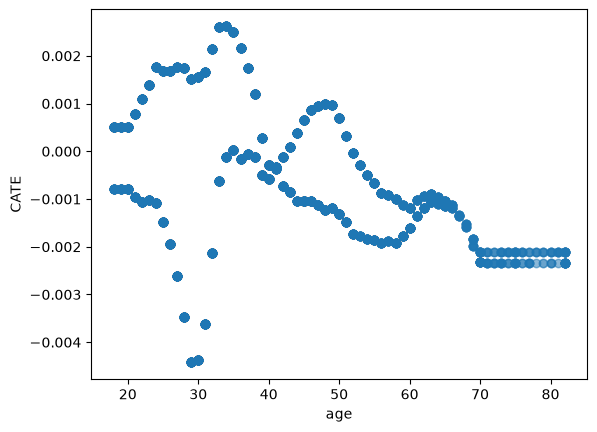

In [89]:
plt.scatter(df['age'], effects, alpha=0.3)
plt.ylabel('CATE')
plt.xlabel('age')

<Axes: xlabel='female'>

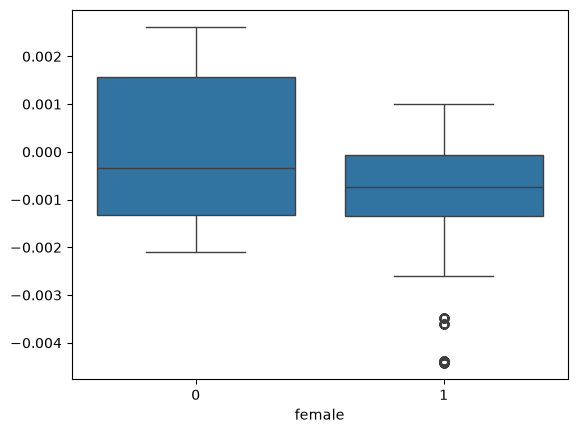

In [91]:

import seaborn as sns
sns.boxplot(x=df['female'], y=effects)

In [92]:
# plt.scatter(df['relation_to_head'], effects, alpha=0.3)
# plt.ylabel('CATE')
# plt.xlabel('relation_to_head')

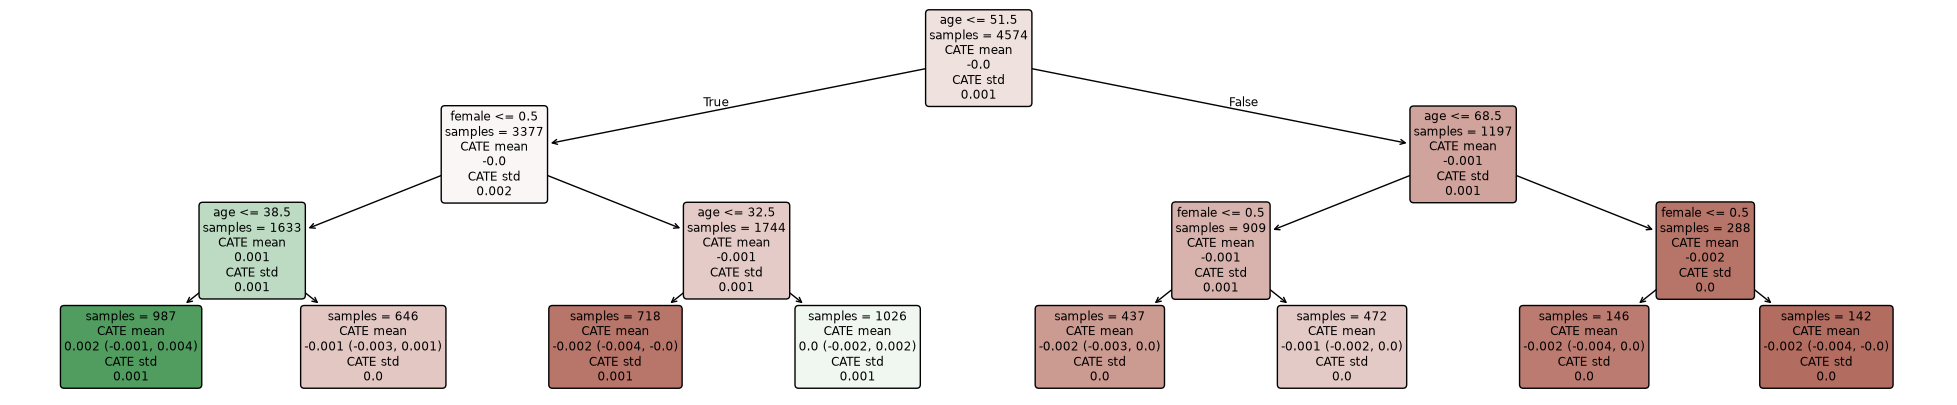

In [100]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=3, min_samples_leaf=10,random_state=42)
intrp.interpret(est, df[X])
plt.figure(figsize=(25, 5))
intrp.plot(feature_names=df[X].columns)

In [ ]:
#COMPARISON OF MEANS AT THE END OF THE CATE DISTRIBUTION (E.G. BOTTOM VS. TOP DECILE)
# NEXT STEP: CALCULATE WHETHER THOSE MEANS ARE STATISTICALLY SIGNIFICANT USING A T-TEST!
cate = effects  # array of CATE estimates, one per row in df

# thresholds for bottom 10% and top 10% of the CATE distribution
low, high = np.percentile(cate, [10, 90])

bottom_decile = df[cate <= low]
top_decile = df[cate >= high]

print("Bottom decile (lowest CATE) - mean age:", bottom_decile['age'].mean())
print("Top decile (highest CATE) - mean age:", top_decile['age'].mean())

print("Bottom decile (lowest CATE) - mean female:", bottom_decile['female'].mean())
print("Top decile (highest CATE) - mean female:", top_decile['female'].mean())

Bottom decile (lowest CATE) - mean age: 49.549815498154985
Top decile (highest CATE) - mean age: 30.804878048780488
Bottom decile (lowest CATE) - mean female: 0.8136531365313653
Top decile (highest CATE) - mean female: 0.0


In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML

# 1. Train/Validation Split
X_tr, X_val, T_tr, T_val, Y_tr, Y_val, W_tr, W_val = train_test_split(
    df[X], df[T], df[Y], df[W], test_size=0.5, random_state=42
)

est = CausalForestDML(
    model_y=first_stage_outcome_model,
    model_t=first_stage_treatment_model,
    discrete_outcome=False,   #use a regression, not a classification
    discrete_treatment=False, #use a regression, not a classification
    n_estimators=1000,        # High number of trees ensures stable causal predictions
    min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
    cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
    random_state=42
)

est.fit(Y_tr, T_tr, X=X_tr, W=W_tr,cache_values=True)

cate_val = est.effect(X_val)         
c = cate_val - np.mean(cate_val)      # Center predictions

est_val = CausalForestDML(
    model_y=first_stage_outcome_model,
    model_t=first_stage_treatment_model,
    discrete_outcome=False,   #use a regression, not a classification
    discrete_treatment=False, #use a regression, not a classification
    n_estimators=1000,        # High number of trees ensures stable causal predictions
    min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
    cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
    random_state=42
)
est_val.fit(Y_val, T_val, X=X_val, W=W_val, cache_values=True)

# Safely extract 1D residuals
Y_res = est_val.residuals_[0]
T_res = est_val.residuals_[1]

X_blp = np.column_stack([T_res, T_res * c])

blp_model = sm.OLS(Y_res, X_blp).fit(cov_type='HC1')
print(blp_model.summary(xname=['ATE_slope', 'CATE_heterogeneity_slope']))

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.8632
Date:                Fri, 14 Aug 2026   Prob (F-statistic):                       0.422
Time:                        16:56:04   Log-Likelihood:                         -394.15
No. Observations:                2287   AIC:                                      792.3
Df Residuals:                    2285   BIC:                                      803.8
Df Model:                           2                                                  
Covariance Type:                  HC1                                                  
                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

In [ ]:









# 5. Build BLP Design Matrix
# Col 1: T_res (Average Treatment Effect proxy)
# Col 2: T_res * c (Heterogeneity / CATE Signal proxy)

# OLS with Heteroskedasticity-Consistent (HC1) Standard Errors
